# Grundlagen der Künstlichen Intelligenz.
# Exercise 2. Search Algorithms: BFS and DFS

**Autor:** Arturo Olivares Martos
***

- **Asignatura:** Grundlagen der Künstlichen Intelligenz.
- **Curso Académico:** 2025-26.
- **Grado:** Doble Grado en Ingeniería Informática y Matemáticas.
- **Grupo:** Erasmus.
- **Profesor:** Gérald Kämmerer
- **Descripción:** Práctica 2 de la asignatura GKI
<!--- **Fecha:** 17 de abril de 2023. -->
<!-- - **Duración:** -->

### 1. Graph Representation and Visualization

Graph Creation and Plotting:
-  Create a graph with at least 6 nodes using the `networkx` library in Python. The graph should be undirected.
-  Plot the graph using `networkx` and `matplotlib`.

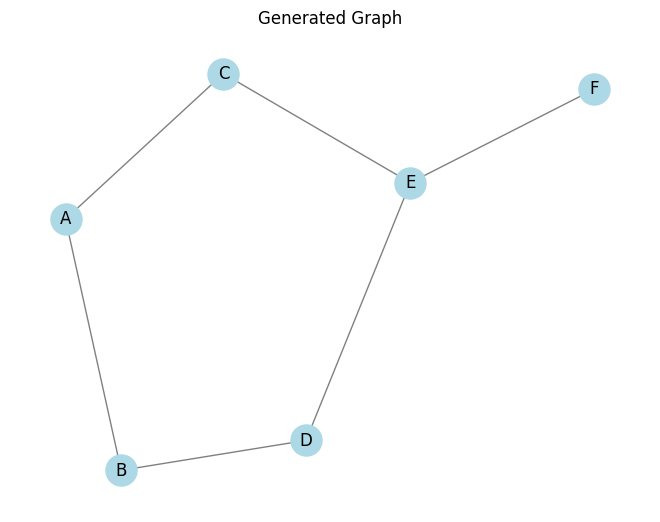

Adjacency List: {'A': ['B', 'C'], 'B': ['A', 'D'], 'C': ['A', 'E'], 'D': ['B', 'E'], 'E': ['C', 'D', 'F'], 'F': ['E']}
Adjacency Matrix:
 [[0. 1. 1. 0. 0. 0.]
 [1. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 1. 0. 1.]
 [0. 0. 0. 0. 1. 0.]]


In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an undirected graph
G = nx.Graph()

# Add nodes and edges
G.add_nodes_from(['A', 'B', 'C', 'D', 'E', 'F'])
G.add_edges_from([('A', 'B'), ('A', 'C'), ('B', 'D'), ('C', 'E'), ('D', 'E'), ('E', 'F')])

# Plot the graph
nx.draw(G, with_labels=True, node_color='lightblue', node_size=500, edge_color='gray')
plt.title("Generated Graph")
plt.show()

# Extract adjacency list
adjacency_list = nx.to_dict_of_lists(G)
print("Adjacency List:", adjacency_list)

# Extract adjacency matrix
adjacency_matrix = nx.to_numpy_array(G)
print("Adjacency Matrix:\n", adjacency_matrix)

### 2. Breadth-First Search (BFS)

- Implement the Breadth-First Search (BFS) algorithm in Python. Your function `bfs(graph, start node)` should take the graph (adjacency list) and a starting node as input and return the order in which nodes are visited.
- Apply BFS starting from node `A` and print the traversal order.
- Explain the order in which nodes are visited and why.

In [7]:
from collections import deque
def bfs(graph, start_node):
    """
    Performs Breadth-First Search (BFS) on the given graph starting from the specified node.
    Args:
        graph (dict): The graph represented as an adjacency list.
        start_node (str): The node from which to start the BFS.
    Returns:
        list: The order in which nodes are visited.
    """

    bfs_order = []
    queue = deque([start_node])
    visited = set()
    visited.add(start_node)

    while queue:
        current_node = queue.popleft()
        bfs_order.append(current_node)

        # Enqueue all unvisited neighbors
        for neighbor in graph[current_node]:
            if neighbor not in visited:
                queue.append(neighbor)
                visited.add(neighbor)
    
    return bfs_order

print("BFS Traversal Order:", bfs(adjacency_list, 'A'))

BFS Traversal Order: ['A', 'B', 'C', 'D', 'E', 'F']


The BFS algorithm explores the graph level by level. It starts at the given starting node (in this case, node `A`) and visits all of its neighbors (`B`, `C`) before moving on to the neighbors of those neighbors. This means that BFS will visit all nodes at the current depth level before moving to the next level. The order of traversal is determined by the structure of the graph and the order in which neighbors are added to the queue.


### 3. Depth-First Search (DFS)

- Implement the Depth-First Search (DFS) algorithm in Python. Your function `dfs(graph, start node)` should take the graph (adjacency list) and a starting node as input and return the order in which nodes are visited.
- Apply DFS starting from node `A` and print the traversal order.
- Explain the order in which nodes are visited and why.
- Compare the traversal order of DFS with that of BFS. What are the key differences?

In [ ]:
def dfs(graph, start_node):
    """
    Performs Depth-First Search (DFS) on the given graph starting from the specified node.
    Args:
        graph (dict): The graph represented as an adjacency list.
        start_node (str): The node from which to start the DFS.
    Returns:
        list: The order in which nodes are visited.
    """

    dfs_order = []
    stack = [start_node]
    visited = set()
    visited.add(start_node)

    while stack:
        current_node = stack.pop()
        dfs_order.append(current_node)

        # Push all unvisited neighbors onto the stack
        for neighbor in reversed(graph[current_node]):
            if neighbor not in visited:
                stack.append(neighbor)
                visited.add(neighbor)
            elif neighbor in stack:
                # TODO: If they are not trees, this is needed, isn't it?
                # Bring the neighbor to the top of the stack
                stack.remove(neighbor)
                stack.append(neighbor)
    
    return dfs_order

def dfs_recursive(graph, start_node):
    """
    Performs Depth-First Search (DFS) on the given graph starting from the specified node using recursion.
    Args:
        graph (dict): The graph represented as an adjacency list.
        start_node (str): The node from which to start the DFS.
    Returns:
        list: The order in which nodes are visited.
    """

    dfs_order = []
    visited = set()

    def dfs_helper(node):
        visited.add(node)
        dfs_order.append(node)

        for neighbor in graph[node]:
            if neighbor not in visited:
                dfs_helper(neighbor)

    dfs_helper(start_node)
    return dfs_order

print("DFS Iterative Traversal Order:", dfs(adjacency_list, 'A'))
print("DFS Recursive Traversal Order:", dfs_recursive(adjacency_list, 'A'))

DFS Iterative Traversal Order: ['A', 'B', 'D', 'E', 'C', 'F']
DFS Recursive Traversal Order: ['A', 'B', 'D', 'E', 'C', 'F']


The DFS algorithm explores the graph by going as deep as possible along each branch before backtracking. Starting from node `A`, DFS will visit one of its neighbors (e.g., `B`), then continue to visit a neighbor of `B` (e.g., `D`), and so on, until it reaches a node with no unvisited neighbors. At that point, it will backtrack to the previous node and explore any remaining neighbors. The order of traversal in DFS is determined by the structure of the graph and the order in which neighbors are added to the stack. The key difference between DFS and BFS is that DFS uses a stack (or recursion) to explore as deep as possible, while BFS uses a queue to explore level by level.

### 4. Path Finding

- Modify the BFS algorithm to find the shortest path from node `A` to node `F`. Your function `bfs_path(graph, start_node, end_node)` should return the path as a list of nodes.
- Modify the DFS algorithm to find any path from node `A` to node `F`. Your function `dfs_path(graph, start_node, end_node)` should return the path as a list of nodes.
- Compare the paths found by BFS and DFS. Which algorithm guarantees the shortest path?

In [28]:
def bfs_path(graph, start_node, end_node):
    """
    Finds the shortest path from start_node to end_node using Breadth-First Search (BFS).
    Args:
        graph (dict): The graph represented as an adjacency list.
        start_node (str): The node from which to start the BFS.
        end_node (str): The target node to find the path to.
    Returns:
        list: The shortest path from start_node to end_node.
    """

    queue = deque([start_node])
    visited = {start_node: None} # Keep track of visited nodes and their parents

    while queue:
        current_node = queue.popleft()
        if current_node == end_node:
            break

        # Enqueue all unvisited neighbors
        for neighbor in graph[current_node]:
            if neighbor not in visited:
                queue.append(neighbor)
                visited[neighbor] = current_node

    # Reconstruct the path
    path = []
    current = end_node
    while current is not None:
        path.append(current)
        current = visited[current]
    path.reverse()

    return path


def dfs_path(graph, start_node, end_node):
    """
    Finds a path from start_node to end_node using Depth-First Search (DFS).
    Args:
        graph (dict): The graph represented as an adjacency list.
        start_node (str): The node from which to start the DFS.
        end_node (str): The target node to find the path to.
    Returns:
        list: A path from start_node to end_node.
    """

    stack = [start_node]
    visited = {start_node: None} # Keep track of visited nodes and their parents

    while stack:
        current_node = stack.pop()
        if current_node == end_node:
            break

        # Push all unvisited neighbors onto the stack
        for neighbor in reversed(graph[current_node]):
            if neighbor not in visited:
                stack.append(neighbor)
                visited[neighbor] = current_node
            elif neighbor in stack:
                stack.remove(neighbor)
                stack.append(neighbor)
                visited[neighbor] = current_node

    # Reconstruct the path
    path = []
    current = end_node
    while current is not None:
        path.append(current)
        current = visited[current]
    path.reverse()

    return path


def dfs_recursive_path(graph, start_node, end_node):
    """
    Finds a path from start_node to end_node using Depth-First Search (DFS) with recursion.
    Args:
        graph (dict): The graph represented as an adjacency list.
        start_node (str): The node from which to start the DFS.
        end_node (str): The target node to find the path to.
    Returns:
        list: A path from start_node to end_node.
    """

    visited = set()
    parent = {start_node: None} # Keep track of visited nodes and their parents

    def dfs_helper(node):
        visited.add(node)
        if node == end_node:
            return True

        for neighbor in graph[node]:
            if neighbor not in visited:
                parent[neighbor] = node
                if dfs_helper(neighbor):
                    return True
        return False

    dfs_helper(start_node)

    # Reconstruct the path
    path = []
    current = end_node
    while current is not None:
        path.append(current)
        current = parent[current]
    path.reverse()

    return path

print("Shortest path from A to F using BFS:", bfs_path(adjacency_list, 'A', 'F'))
print("Path from A to F using DFS:", dfs_path(adjacency_list, 'A', 'F'))
print("Path from A to F using recursive DFS:", dfs_recursive_path(adjacency_list, 'A', 'F'))

Shortest path from A to F using BFS: ['A', 'C', 'E', 'F']
Path from A to F using DFS: ['A', 'B', 'D', 'E', 'F']
Path from A to F using recursive DFS: ['A', 'B', 'D', 'E', 'F']


As mentioned earlier, BFS guarantees the shortest path in an unweighted graph because it explores all nodes at the present depth level before moving on to the next level. In contrast, DFS does not guarantee the shortest path because it may explore a longer path first before backtracking and finding a shorter one. Therefore, the path found by BFS will always be the shortest path from node `A` to node `F`, while the path found by DFS may not be the shortest.

### 5. Kahn’s Algorithm (Topological Sorting)

You are responsible for the course planning at a university. For a specific module, there are several lectures that partially build upon each other. Your task is to find an order in which all lectures can be attended without attending a lecture before one of its prerequisites.

Lectures (Nodes):
- Math 1, Math 2, Computer Science 1, Computer Science 2,Databases, Algorithms, Software Development

Dependencies (directed edges "must be attended before"):
-  Math 1 -> Math 2
- Computer Science 1 -> Computer Science 2
- Computer Science 1 -> Algorithms
- Math 2 -> Algorithms
- Computer Science 2 -> Databases
- Algorithms -> Software Development

1. Create the graph
- Represent the directed graph as an adjacency list.
- For each node, note the in-degree (number of incoming edges).

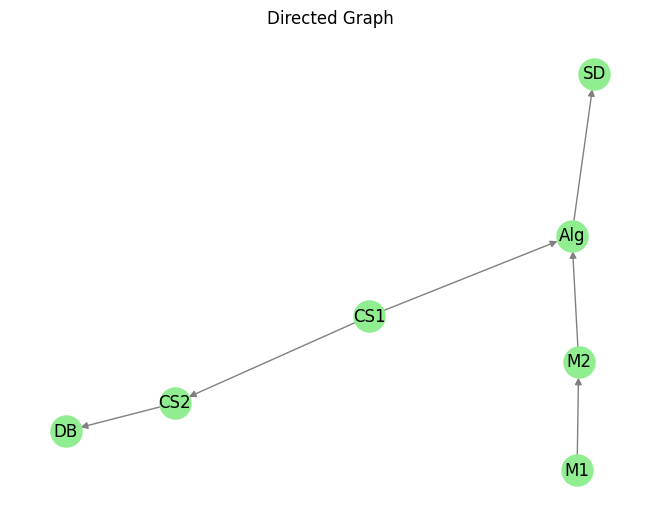

In [ ]:
# Oriented graph
G2 = nx.DiGraph()

G2.add_nodes_from(['M1', 'M2', 'CS1', 'CS2', 'Alg', 'DB', 'SD'])
G2.add_edges_from([('M1', 'M2'), ('CS1', 'CS2'), ('CS1', 'Alg'), ('M2', 'Alg'), ('CS2', 'DB'), ('Alg', 'SD')])

# Plot the directed graph
nx.draw(G2, with_labels=True, node_color='lightgreen', node_size=500, edge_color='gray', arrows=True)
plt.title("Directed Graph")
plt.show()


Apply Kahn’s Algorithm

In [31]:
def kahn_topological_sort(graph):
    """
    Performs Kahn's algorithm for topological sorting on a directed graph.
    Args:
        graph (dict): The directed graph represented as an adjacency list.
    Returns:
        list: A topologically sorted order of the nodes, or an empty list if a cycle is detected.
    """

    # Calculate in-degrees of all nodes
    in_degree = {node: 0 for node in graph}
    for node in graph:
        for neighbor in graph[node]:
            in_degree[neighbor] += 1

    # Initialize a queue with all nodes that have in-degree 0
    queue = deque([node for node in graph if in_degree[node] == 0])
    topological_order = []

    while queue:
        if len(queue) > 1:
            print("Multiple nodes with in-degree 0 detected, topological order may not be unique:", list(queue))
        current_node = queue.popleft()
        topological_order.append(current_node)

        # Decrease the in-degree of neighboring nodes
        for neighbor in graph[current_node]:
            in_degree[neighbor] -= 1
            if in_degree[neighbor] == 0:
                queue.append(neighbor)

    # Check if topological sort is possible (i.e., no cycles)
    if len(topological_order) == len(graph):
        return topological_order
    else:
        return []  # Cycle detected, no topological order exists
    

print("Topological Sort using Kahn's Algorithm:", kahn_topological_sort(nx.to_dict_of_lists(G2)))

Multiple nodes with in-degree 0 detected, topological order may not be unique: ['M1', 'CS1']
Multiple nodes with in-degree 0 detected, topological order may not be unique: ['CS1', 'M2']
Multiple nodes with in-degree 0 detected, topological order may not be unique: ['M2', 'CS2']
Multiple nodes with in-degree 0 detected, topological order may not be unique: ['CS2', 'Alg']
Multiple nodes with in-degree 0 detected, topological order may not be unique: ['Alg', 'DB']
Multiple nodes with in-degree 0 detected, topological order may not be unique: ['DB', 'SD']
Topological Sort using Kahn's Algorithm: ['M1', 'CS1', 'M2', 'CS2', 'Alg', 'DB', 'SD']
